In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyprojroot import here
import importlib.util

_spec = importlib.util.spec_from_file_location("opinion_functions", here() / "src" / "opinion_functions.py")
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
fun = _mod

_spec = importlib.util.spec_from_file_location("generate_homophilic_graph_asymmetric", here() / "src" / "generate_homophilic_graph_asymmetric.py")
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
homophilic_barabasi_albert_graph_assym = _mod.homophilic_barabasi_albert_graph_assym

## Parameters

Regime: `h_ss = h_oo = 0.70` (symmetric homophily), `m = 10`.
Bayesian prior: `delta = 0.1`, `gamma = 0.5`.

Conversion: `h_ba = 1 − h_ss`, `h_ab = 1 − h_oo` (generator convention).

In [2]:
# ── simulation parameters ─────────────────────────────────────────────────
N               = 1000
m               = 10
minority_frac   = 1 / 3          # opponents are 1/3 of the population
fs              = 1 - minority_frac   # actual supporter fraction ≈ 0.667

h_ss = 0.70   # supporter same-group homophily
h_oo = 0.70   # opponent  same-group homophily

# convert to generator convention:
#   h_ab = minority cross-group attach prob = 1 - h_oo
#   h_ba = majority cross-group attach prob = 1 - h_ss
h_ab = 1 - h_oo
h_ba = 1 - h_ss

delta = 0.1
gamma = 0.5

num_sims = 1
rng = np.random.default_rng(seed=42)

In [3]:
# ── run simulation and collect perceived opinions ──────────────────────────
seed_val = int(rng.integers(0, 2**31))
G, minority_nodes = homophilic_barabasi_albert_graph_assym(
    N, m, minority_frac,
    h_ab=h_ab, h_ba=h_ba,
    seed=seed_val
)
true_op, perceived = fun.generate_perceived_opinion(
    G, minority_nodes, media_nodes=[],
    narcissistic=False,
    bayes=True, delta=delta, gamma=gamma
)
true_split = np.array(true_op)
perc_split = np.array(perceived)

In [4]:
# ── style constants ────────────────────────────────────────────────────────
SMALL_SIZE  = 8
MEDIUM_SIZE = 9
COL_BLACK    = '#222222'
COL_BAR      = '#c8c8c8'
COL_SUPP     = '#19bdff'
COL_SUPP_DARK = '#0088cc'
COL_OPP      = '#f2d138'
COL_OPP_DARK = '#b89a00'

plt.rc('font',   size=SMALL_SIZE)
plt.rc('axes',   titlesize=SMALL_SIZE)
plt.rc('axes',   labelsize=MEDIUM_SIZE)
plt.rc('xtick',  labelsize=SMALL_SIZE)
plt.rc('ytick',  labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)

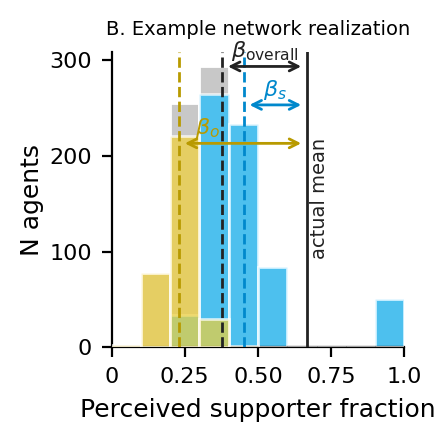

mean_supp=0.452, mean_opp=0.231, mean_all=0.379, fs=0.667
beta_ov=0.288, beta_s=0.215, beta_o=0.436


In [5]:
# ── Panel B: supporters vs opponents overlaid, N agents (no legend) ────────
perc_supp = perc_split[true_split == 1]
perc_opp  = perc_split[true_split == 0]

fig, ax = plt.subplots(figsize=(2.25, 2.25), dpi=200)
bins_edges = np.linspace(0, 1, 11)

ax.hist(perc_split, bins=bins_edges, histtype='bar',
        color=COL_BAR,  edgecolor='white', alpha=1.0, zorder=1)
ax.hist(perc_supp,  bins=bins_edges, histtype='bar',
        color=COL_SUPP, edgecolor='white', alpha=0.7, zorder=2)
ax.hist(perc_opp,   bins=bins_edges, histtype='bar',
        color=COL_OPP,  edgecolor='white', alpha=0.7, zorder=3)
sns.despine(ax=ax)

ymax_s    = ax.get_ylim()[1]
mean_supp = perc_supp.mean()
mean_opp  = perc_opp.mean()
mean_all  = perc_split.mean()

ax.axvline(fs, color=COL_BLACK, linestyle='-', linewidth=1, zorder=5)
ax.text(fs + 0.01, ymax_s * 0.30, 'actual mean', rotation=90,
        color=COL_BLACK, fontsize=SMALL_SIZE - 1, va='bottom', zorder=5)

ax.axvline(mean_supp, color=COL_SUPP_DARK, linestyle='--', linewidth=1, zorder=4)
ax.axvline(mean_opp,  color=COL_OPP_DARK,  linestyle='--', linewidth=1, zorder=4)
ax.axvline(mean_all,  color=COL_BLACK,      linestyle='--', linewidth=1, zorder=4)

arrow_y_ov = ymax_s * 0.95
arrow_y_s  = ymax_s * 0.82
arrow_y_o  = ymax_s * 0.69

ax.annotate('', xy=(fs, arrow_y_ov), xytext=(mean_all, arrow_y_ov),
            arrowprops=dict(arrowstyle='<->', color=COL_BLACK, lw=1), zorder=5)
ax.text((mean_all + fs) / 2, arrow_y_ov + ymax_s * 0.01,
        r'$\beta_{\mathrm{overall}}$', ha='center', va='bottom',
        fontsize=SMALL_SIZE, color=COL_BLACK, zorder=5)

ax.annotate('', xy=(fs, arrow_y_s), xytext=(mean_supp, arrow_y_s),
            arrowprops=dict(arrowstyle='<->', color=COL_SUPP_DARK, lw=1), zorder=5)
ax.text((mean_supp + fs) / 2, arrow_y_s + ymax_s * 0.01,
        r'$\beta_s$', ha='center', va='bottom',
        fontsize=SMALL_SIZE, color=COL_SUPP_DARK, zorder=5)

ax.annotate('', xy=(fs, arrow_y_o), xytext=(mean_opp, arrow_y_o),
            arrowprops=dict(arrowstyle='<->', color=COL_OPP_DARK, lw=1), zorder=5)
ax.text((mean_opp + fs) / 2 - 0.12, arrow_y_o + ymax_s * 0.01,
        r'$\beta_o$', ha='center', va='bottom',
        fontsize=SMALL_SIZE, color=COL_OPP_DARK, zorder=5)

ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(['0', '0.25', '0.50', '0.75', '1.0'])
ax.set_xlabel('Perceived supporter fraction', labelpad=4)
ax.set_ylabel('N agents', labelpad=2)
ax.set_title('B. Example network realization', fontsize=SMALL_SIZE - 1)

plt.tight_layout()
plt.savefig(here('figures/figure_histogram_example_grouped.pdf'), dpi=200)
plt.show()
print(f'mean_supp={mean_supp:.3f}, mean_opp={mean_opp:.3f}, mean_all={mean_all:.3f}, fs={fs:.3f}')
print(f'beta_ov={fs-mean_all:.3f}, beta_s={fs-mean_supp:.3f}, beta_o={fs-mean_opp:.3f}')


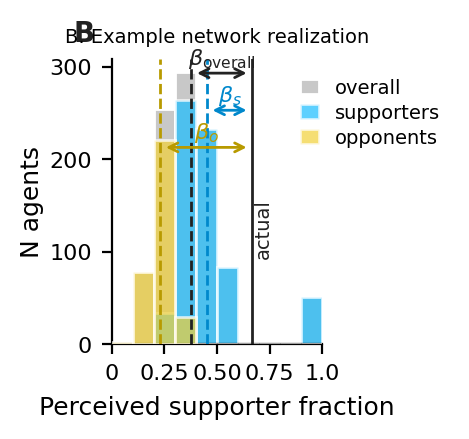

Saved figure_histogram_example_grouped_legend.pdf


In [6]:
# ── Panel B with legend ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(2.25, 2.25), dpi=200)
bins_edges = np.linspace(0, 1, 11)

ax.hist(perc_split, bins=bins_edges, histtype='bar',
        color=COL_BAR,  edgecolor='white', alpha=1.0, zorder=1)
ax.hist(perc_supp,  bins=bins_edges, histtype='bar',
        color=COL_SUPP, edgecolor='white', alpha=0.7, zorder=2)
ax.hist(perc_opp,   bins=bins_edges, histtype='bar',
        color=COL_OPP,  edgecolor='white', alpha=0.7, zorder=3)
sns.despine(ax=ax)

ymax_s = ax.get_ylim()[1]

ax.axvline(fs, color=COL_BLACK, linestyle='-', linewidth=1, zorder=5)
ax.text(fs + 0.01, ymax_s * 0.30, 'actual', rotation=90,
        color=COL_BLACK, fontsize=SMALL_SIZE - 1, va='bottom', zorder=5)

ax.axvline(mean_supp, color=COL_SUPP_DARK, linestyle='--', linewidth=1, zorder=4)
ax.axvline(mean_opp,  color=COL_OPP_DARK,  linestyle='--', linewidth=1, zorder=4)
ax.axvline(mean_all,  color=COL_BLACK,      linestyle='--', linewidth=1, zorder=4)

arrow_y_ov = ymax_s * 0.95
arrow_y_s  = ymax_s * 0.82
arrow_y_o  = ymax_s * 0.69

ax.annotate('', xy=(fs, arrow_y_ov), xytext=(mean_all, arrow_y_ov),
            arrowprops=dict(arrowstyle='<->', color=COL_BLACK, lw=1), zorder=5)
ax.text((mean_all + fs) / 2, arrow_y_ov + ymax_s * 0.01,
        r'$\beta_{\mathrm{overall}}$', ha='center', va='bottom',
        fontsize=SMALL_SIZE, color=COL_BLACK, zorder=5)

ax.annotate('', xy=(fs, arrow_y_s), xytext=(mean_supp, arrow_y_s),
            arrowprops=dict(arrowstyle='<->', color=COL_SUPP_DARK, lw=1), zorder=5)
ax.text((mean_supp + fs) / 2, arrow_y_s + ymax_s * 0.01,
        r'$\beta_s$', ha='center', va='bottom',
        fontsize=SMALL_SIZE, color=COL_SUPP_DARK, zorder=5)

ax.annotate('', xy=(fs, arrow_y_o), xytext=(mean_opp, arrow_y_o),
            arrowprops=dict(arrowstyle='<->', color=COL_OPP_DARK, lw=1), zorder=5)
ax.text((mean_opp + fs) / 2, arrow_y_o + ymax_s * 0.01,
        r'$\beta_o$', ha='center', va='bottom',
        fontsize=SMALL_SIZE, color=COL_OPP_DARK, zorder=5)

ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(['0', '0.25', '0.50', '0.75', '1.0'])
ax.set_xlabel('Perceived supporter fraction', labelpad=4)
ax.set_ylabel('N agents', labelpad=2)
ax.set_title('B. Example network realization', fontsize=SMALL_SIZE - 1)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=COL_BAR,  edgecolor='white', label='overall'),
    Patch(facecolor=COL_SUPP, edgecolor='white', alpha=0.7, label='supporters'),
    Patch(facecolor=COL_OPP,  edgecolor='white', alpha=0.7, label='opponents'),
]
ax.legend(handles=legend_handles,
          bbox_to_anchor=(0.80, 1.0), loc='upper left',
          fontsize=SMALL_SIZE - 1, frameon=True,
          framealpha=0.85, edgecolor='none',
          handlelength=1.0, handleheight=0.8,
          borderpad=0.5, labelspacing=0.3)

ax.text(-0.08, 1.04, 'B', transform=ax.transAxes,
        fontsize=MEDIUM_SIZE + 1, fontweight='bold',
        va='bottom', ha='right', color=COL_BLACK)

plt.tight_layout()
plt.savefig(here('figures/figure_histogram_example_grouped_legend.pdf'), dpi=200)
plt.show()
print('Saved figure_histogram_example_grouped_legend.pdf')


### Caption for Panel B

**B. Example network realization.**
Distribution of Bayesian-rescaled perceived supporter fractions across all $N=1000$ agents
in a single simulated Barabási–Albert network with $m=10$, symmetric homophily
$h_{ss} = h_{oo} = 0.70$, prior strength $\delta=0.1$, and uncertainty $\gamma=0.5$.
Grey bars show the full population; blue bars show supporters (majority, $f_s=2/3$);
yellow bars show opponents (minority, $f_o=1/3$).
The solid vertical line marks actual supporter prevalence $f_s$;
dashed lines mark the mean perceived fraction for each group.
Double-headed arrows indicate group-level misperception
($\beta_s$ for supporters, $\beta_o$ for opponents)
and overall misperception $\beta_{\mathrm{overall}}$.